# Feature Engineering on Primary Land Use Tax Lot Output (PLUTO) Dataset:

----

# Import Libraries:

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F 
from pyspark.sql.functions import * 
from shapely.geometry import Point
import matplotlib.pyplot as plt
import pandas as pd 
import geopandas as gpd
import seaborn as sns
import os

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("feature_engineering_pluto")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.network.timeout", "600s")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.rpc.askTimeout", "600s")
    .config("spark.driver.memory", "100G")
    .config("spark.executor.memory", "100G")
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.sql.debug.maxToStringFields", "1000")
    .getOrCreate()
)

24/09/03 13:00:51 WARN Utils: Your hostname, Cocos-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.12.220.208 instead (on interface en0)
24/09/03 13:00:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/09/03 13:00:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/09/03 13:00:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Read Files:

Read Preprocessed PLUTO Parquet Files:

In [4]:
base_dir = "../data"

In [4]:
pluto_path = base_dir + '/curated/pluto/preprocessed_pluto'
pluto_sdf = spark.read.parquet(pluto_path)
pluto_sdf.show(5)

+-------+--------------+----------+-----------+
|borough|building_class|  latitude|  longitude|
+-------+--------------+----------+-----------+
|     SI|             F|40.6288711|-74.0750604|
|     SI|             B|40.6154356|-74.0746779|
|     SI|             B|40.6155098| -74.074487|
|     SI|             B|40.6154741|-74.0745662|
|     SI|             B|40.6152734|-74.0750307|
+-------+--------------+----------+-----------+
only showing top 5 rows



In [5]:
pluto_sdf.printSchema()

root
 |-- borough: string (nullable = true)
 |-- building_class: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)



Read taxi zone lookup file:

In [6]:
zone_lookup_path = base_dir + '/raw/taxi_zone/taxi_zone_lookup.parquet'
zone_lookup_sdf = spark.read.parquet(zone_lookup_path)
zone_lookup_sdf.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows



In [7]:
num_rows = zone_lookup_sdf.count()
print(f"Number of rows: {num_rows}")

columns = zone_lookup_sdf.columns
num_columns = len(columns)
print(f"Number of columns: {num_columns}")

Number of rows: 265
Number of columns: 4


In [8]:
# Convert taxi zone lookup parquet file to Pandas dataframe
zone_lookup_df = zone_lookup_sdf.toPandas()
zone_lookup_df.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Read taxi zone shape file:

In [5]:
zone_shapefile_path = base_dir + '/raw/taxi_zone/taxi_zones.shp'
zone_shapefile = gpd.read_file(zone_shapefile_path)
zone_shapefile.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [10]:
zone_shapefile.shape

(263, 7)

# Create the  Full Zone Dataframe `zone_gdf`:

`zone_gdf` includes geometry, location ID, borough and other related information.

We firstly combine `latitude` and `longitude` columns in PLUTO dataset and convert them to geopandas dataframe format:

In [47]:
# Convert PLUTO parquet file to Pandas-on-Spark DataFrame (psdf)
pluto_psdf = pluto_sdf.to_pandas_on_spark()

# Convert PLUTO Pandas-on-Spark DataFrame to psdf Pandas DataFrame
pluto_df = pluto_psdf.to_pandas()

# Create GeoDataFrame
pluto_df['geometry'] = pluto_df.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
pluto_gdf = gpd.GeoDataFrame(pluto_df, geometry='geometry')

# Set the coordinate reference system
pluto_gdf.crs = 'epsg:4326'

pluto_gdf = pluto_gdf.drop(columns=['longitude', 'latitude'])

/Users/apple/anaconda3/lib/python3.11/site-packages/pyspark/sql/dataframe.py:5723: FutureWarning: DataFrame.to_pandas_on_spark is deprecated. Use DataFrame.pandas_api instead.
  warnings.warn(
/Users/apple/anaconda3/lib/python3.11/site-packages/pyspark/pandas/utils.py:1016: PandasAPIOnSparkAdviceWarning: `to_pandas` loads all data into the driver's memory. It should only be used if the resulting pandas DataFrame is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


In [48]:
pluto_gdf.head()

,borough,building_class,geometry
0,SI,F,POINT (-74.07506 40.62887)
1,SI,B,POINT (-74.07468 40.61544)
2,SI,B,POINT (-74.07449 40.61551)
3,SI,B,POINT (-74.07457 40.61547)
4,SI,B,POINT (-74.07503 40.61527)


Then convert the `geometry` in taxi zone shapefile to longitude and latitude format in order to perform spatial join with PLUTO dataset later:

In [49]:
zone_shapefile['geometry'] = zone_shapefile['geometry'].to_crs(epsg=4326)
zone_shapefile.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


Merge the taxi zone lookup dataframe and the taxi zone shapefile on `LocationID`:

In [50]:
zone_gdf = gpd.GeoDataFrame(pd.merge(zone_lookup_df, zone_shapefile, 
                                    on='LocationID', how='inner')).drop(['Zone','Borough'], axis=1)

# Rename and drop columns
zone_gdf = zone_gdf.rename({'LocationID':'location_id'}, axis=1)
zone_gdf.drop('OBJECTID', axis=1, inplace=True)
zone_gdf.head()

,location_id,service_zone,Shape_Leng,Shape_Area,zone,borough,geometry
0,1,EWR,0.116357,0.000782,Newark Airport,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,Boro Zone,0.433470,0.004866,Jamaica Bay,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,Boro Zone,0.084341,0.000314,Allerton/Pelham Gardens,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,Yellow Zone,0.043567,0.000112,Alphabet City,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,Boro Zone,0.092146,0.000498,Arden Heights,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


# Create the Full PLUTO Dataframe `pluto_df`:

`pluto_df` will contain all information need for each building, including building class, geometry, service zone, borough and so on.

Perform spatial join on `pluto_gdf` and `zone_gdf`:

In [51]:
pluto_df = gpd.sjoin(pluto_gdf, zone_gdf, predicate='within')\
              .drop(['index_right', 'borough_left', 'Shape_Leng', 'Shape_Area'], axis=1)
pluto_df.head()

,building_class,geometry,location_id,service_zone,zone,borough_right
0,F,POINT (-74.07506 40.62887),221,Boro Zone,Stapleton,Staten Island
1,B,POINT (-74.07468 40.61544),221,Boro Zone,Stapleton,Staten Island
2,B,POINT (-74.07449 40.61551),221,Boro Zone,Stapleton,Staten Island
3,B,POINT (-74.07457 40.61547),221,Boro Zone,Stapleton,Staten Island
4,B,POINT (-74.07503 40.61527),221,Boro Zone,Stapleton,Staten Island


In [52]:
pluto_df.shape

(856087, 6)

In [53]:
# Rename and drop columns
pluto_df = pluto_df.rename({'LocationID':'location_id',
                            'borough_right':'borough'}, axis=1)

pluto_df.head()

,building_class,geometry,location_id,service_zone,zone,borough
0,F,POINT (-74.07506 40.62887),221,Boro Zone,Stapleton,Staten Island
1,B,POINT (-74.07468 40.61544),221,Boro Zone,Stapleton,Staten Island
2,B,POINT (-74.07449 40.61551),221,Boro Zone,Stapleton,Staten Island
3,B,POINT (-74.07457 40.61547),221,Boro Zone,Stapleton,Staten Island
4,B,POINT (-74.07503 40.61527),221,Boro Zone,Stapleton,Staten Island


# Save Merged Datasets:

Zone geographical dataset:

In [61]:
zone_gdf_dir = base_dir + '/developed/merged_data'
file_name = 'zone_gdf.csv'
zone_gdf_path = os.path.join(zone_gdf_dir, file_name)
zone_gdf.to_csv(zone_gdf_path, index=False)

PLUTO dataset (include building class) :

In [62]:
pluto_df_dir = base_dir + '/developed/merged_data'
file_name = 'pluto_df.csv'
pluto_df_path = os.path.join(pluto_df_dir, file_name)
pluto_df.to_csv(pluto_df_path, index=False)

# Visulization:

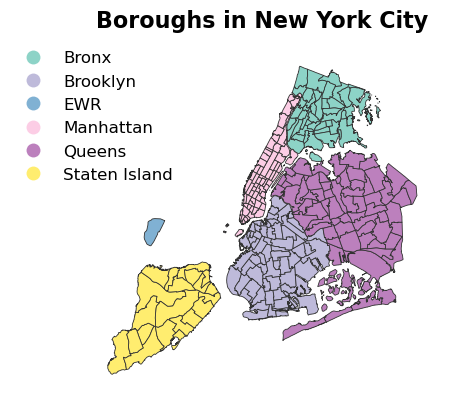

In [64]:
zone_gdf.plot(column='borough', categorical=True, cmap='Set3', linewidth=0.6, 
                    edgecolor='0.2', legend=True, 
                    legend_kwds={'bbox_to_anchor': (0.3, 1.0), 'fontsize': 12, 'frameon': False})

plt.axis('off')
plt.title('Boroughs in New York City', fontsize=16, fontweight='bold')
plt.grid(False) 
plt.margins(0.1)

plt.show()

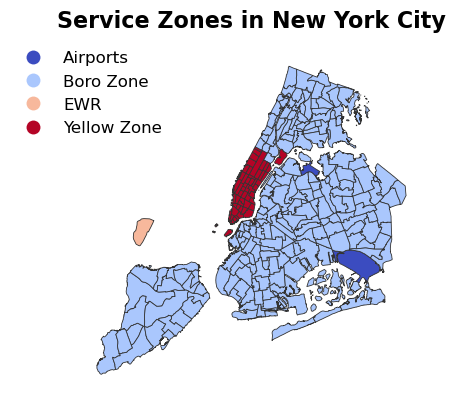

In [65]:
zone_gdf.plot(column='service_zone', categorical=True, cmap='coolwarm', linewidth=0.6, 
                    edgecolor='0.2', legend=True, 
                    legend_kwds={'bbox_to_anchor': (0.3, 1.0), 'fontsize': 12, 'frameon': False})

plt.axis('off')
plt.title('Service Zones in New York City', fontsize=16, fontweight='bold')
plt.grid(False) 
plt.margins(0.1)

plt.show()